In [10]:
import numpy as np

In [11]:
pip install pylandau

  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [37 lines of output]
      Compiling pyLandau/cpp/pylandau.pyx because it changed.
      [1/1] Cythonizing pyLandau/cpp/pylandau.pyx
      
      Error compiling Cython file:
      ------------------------------------------------------------
      ...
          double gaussPDF(const double & x, const double & mu, const double & sigma)
      
      
      cdef data_to_numpy_array_double(cnp.double_t * ptr, cnp.npy_intp N):
          cdef cnp.ndarray[cnp.double_t, ndim = 1] arr = cnp.PyArray_SimpleNewFromData(1, < cnp.npy_intp * > & N, cnp.NPY_DOUBLE, < cnp.double_t * > ptr)
          PyArray_ENABLEFLAGS(arr, cnp.NPY_OWNDATA)
                                      ^
      ------------------------------------------------------------
      pyLandau/cpp/pylandau.pyx:30:32: cim

In [7]:
#num of template samples, adjust as needed
W=32

#gaus params
sigma=5
center = W//2

#x-axis
x=np.arange(W)

#gaus equ
template_g = np.exp(-(x-center)**2/(2*sigma**2))

#normalize so peak = 1
template_g = template_g / np.max(template_g)

#scale to integers
template_g = np.round(template_g*64)

#convert to integers
template_g = template_g.astype(int)

print(template_g)

#save to memory
with open("template_g.mem", "w") as f:
    for value in template_g:
        f.write(f"{value:02x}\n") 

[ 0  1  1  2  4  6  9 13 18 24 31 39 46 53 59 63 64 63 59 53 46 39 31 24
 18 13  9  6  4  2  1  1]


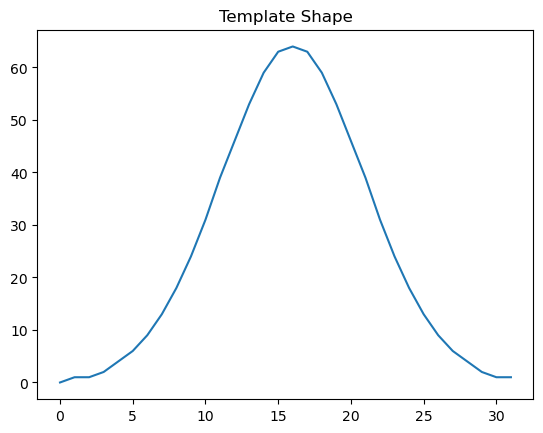

In [8]:
import matplotlib.pyplot as plt
plt.plot(template_g)
plt.title("Template Shape")
plt.show()

[ 0  0  0  0  0  1  5 19 40 57 64 63 57 49 40 33 26 21 16 13 10  8  6  5
  4  3  2  2  1  1  1  1]


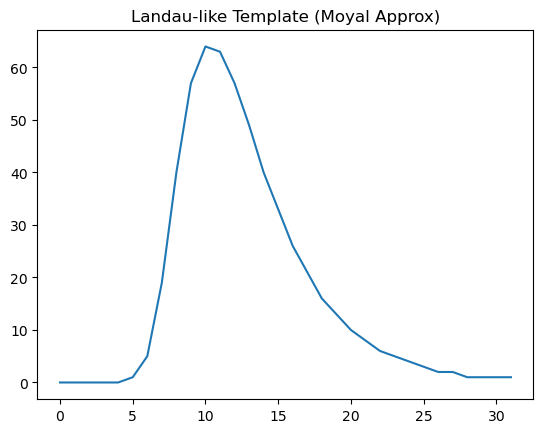

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import moyal

W = 32

# x range
x = np.linspace(-5, 10, W)

# Moyal (Landau approximation)
template_l = moyal.pdf(x)

# normalize
template_l = template_l / np.max(template_l)

# scale to integers for FPGA
template_l = np.round(template_l * 64).astype(int)

print(template_l)

# save to template_l.mem
with open("template_l.mem","w") as f:
    for v in template_l:
        f.write(f"{v:02x}\n")

# visualize
plt.plot(template_l)
plt.title("Landau-like Template (Moyal Approx)")
plt.show()